# Notebook 5 - Benchmarks, m&eacute;tricas y an&aacute;lisis final

N5 cierra el pipeline completo: compara la estrategia de momentum frente al S&amp;P 500 (SPY), mide retorno y riesgo con las m&eacute;tricas obligatorias del enunciado, diagnostica el impacto operativo de fricciones reales (comisiones, no-fills, salidas proxy) y cuantifica la robustez estad&iacute;stica con 25 millones de carteras aleatorias v&iacute;a Monte Carlo directo.

La pregunta central que N5 responde es: **&iquest;aporta valor la estrategia despu&eacute;s de costes y restricciones reales, o podr&iacute;a obtenerse un resultado equivalente eligiendo activos al azar?** La respuesta se apoya en evidencia num&eacute;rica, no en intuici&oacute;n.

**Artefactos de entrada (producidos por N1-N4):**

| Fuente | Artefacto | Prop&oacute;sito |
|---|---|---|
| N1 | `n1_runtime_params.csv`, `n1_benchmark_provenance.csv` | Par&aacute;metros y benchmark |
| N2 | `n2_signals_input.parquet` | Universo elegible para Monte Carlo |
| N4 | `n4_portfolio_daily.csv`, `n4_orders_log.csv` | Equity y &oacute;rdenes ejecutadas |
| N4 | `n4_cost_summary.csv`, `n4_rebalance_summary.csv`, `n4_checks.csv` | Costes y controles |

---

## 1. Configuraci&oacute;n y funciones de medida

Se importan las librer&iacute;as y se definen todas las funciones de medida de rendimiento en un &uacute;nico bloque. Las funciones siguen las convenciones acad&eacute;micas est&aacute;ndar: anualizaci&oacute;n con ra&iacute;z de 252 para volatilidad y Sharpe, desviaci&oacute;n muestral (`ddof=1`) y tasa libre de riesgo configurable (fijada en 0% como caso base conservador). El Sortino usa solo la desviaci&oacute;n de retornos negativos, y el alpha de Jensen se computa v&iacute;a la formulaci&oacute;n cl&aacute;sica del CAPM con beta estimada por covarianza/varianza.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# --- Rutas de entrada ---
N1_RUNTIME  = "data/processed/n1_runtime_params.csv"
N1_BENCH    = "data/processed/n1_benchmark_provenance.csv"
N2_SIGNALS  = "data/processed/n2_signals_input.parquet"
N4_DAILY    = "data/processed/n4_portfolio_daily.csv"
N4_ORDERS   = "data/processed/n4_orders_log.csv"
N4_COSTS    = "data/processed/n4_cost_summary.csv"
N4_REBAL    = "data/processed/n4_rebalance_summary.csv"
N4_CHECKS   = "data/processed/n4_checks.csv"

# --- Supuestos ---
TRADING_DAYS = 252
RF_ANNUAL = 0.0
RF_DAILY = (1 + RF_ANNUAL) ** (1 / TRADING_DAYS) - 1

# --- Parametros Monte Carlo ---
N_MONKEYS = 25_000_000
MONKEY_SEED = 42
MONKEY_K = 20
MONKEY_COST = np.nan
MONKEY_COST_EXPECTED = 0.0046
MONKEY_BATCH = 250_000
MONKEY_PLOT_N = 1_000_000


def fail_if(condition, message):
    if condition:
        raise ValueError(message)


def as_bool(series):
    return series.astype(str).str.strip().str.lower().isin({"true", "1", "yes", "y"})


def cagr(ret, days=252):
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    total = float((1 + ret).prod())
    years = len(ret) / days
    return total ** (1 / years) - 1 if years > 0 else np.nan


def ann_vol(ret, days=252):
    return float(ret.dropna().std(ddof=1) * np.sqrt(days))


def sharpe(ret, rf=0.0, days=252):
    x = ret.dropna() - rf
    den = x.std(ddof=1)
    return float(np.sqrt(days) * x.mean() / den) if den > 0 else np.nan


def sortino(ret, rf=0.0, days=252):
    x = ret.dropna() - rf
    down = x[x < 0].std(ddof=1)
    return float(np.sqrt(days) * x.mean() / down) if down > 0 else np.nan


def max_dd(ret):
    w = (1 + ret.dropna()).cumprod()
    return float((w / w.cummax() - 1).min()) if len(w) > 0 else np.nan


def beta_alpha(strat, bench, rf=0.0, days=252):
    x = pd.concat([strat, bench], axis=1).dropna()
    x.columns = ["s", "b"]
    if len(x) < 2:
        return np.nan, np.nan
    es, eb = x["s"] - rf, x["b"] - rf
    var_b = eb.var(ddof=1)
    if var_b <= 0:
        return np.nan, np.nan
    b = es.cov(eb) / var_b
    a = (1 + es.mean() - b * eb.mean()) ** days - 1
    return float(b), float(a)


def sample_no_replace(rng, n_rows, n_assets, k):
    # Muestreo sin reemplazo por fila usando reintento solo en filas con colisiones.
    fail_if(k > n_assets, f"k={k} > n_assets={n_assets}")
    idx = rng.integers(0, n_assets, size=(n_rows, k), dtype=np.int32)
    if k <= 1:
        return idx
    while True:
        bad = (np.diff(np.sort(idx, axis=1), axis=1) == 0).any(axis=1)
        n_bad = int(bad.sum())
        if n_bad == 0:
            break
        idx[bad] = rng.integers(0, n_assets, size=(n_bad, k), dtype=np.int32)
    return idx


print("Configuracion lista.")
print(f"  Monte Carlo: {N_MONKEYS:,} monos, k={MONKEY_K}, coste=2*fee_rate (runtime)")
print(f"  Rf annual:   {RF_ANNUAL:.2%}, Trading days: {TRADING_DAYS}")



Configuracion lista.
  Monte Carlo: 25,000,000 monos, k=20, coste=2*fee_rate (runtime)
  Rf annual:   0.00%, Trading days: 252


In [2]:
# --- Cache Monte Carlo directo ---
FORCE_RECOMPUTE_MONKEYS = False  # True => recalcula y sobrescribe

MC_DIRECT_WEALTH_NPY  = "data/processed/n5_mc_direct_wealth.npy"
MC_DIRECT_SUMMARY_CSV = "data/processed/n5_mc_direct_summary.csv"
MC_DIRECT_QUANT_CSV   = "data/processed/n5_mc_direct_quantiles.csv"
MC_DIRECT_SAMPLE_CSV  = "data/processed/n5_mc_direct_sample.csv"



---

## 2. Carga de artefactos y ventana com&uacute;n

Se cargan los artefactos de N1 a N4 y el benchmark (SPY). La intersecci&oacute;n temporal entre la serie diaria del portfolio y la serie del SPY define la **ventana com&uacute;n** sobre la que se calculan todas las m&eacute;tricas comparativas. Esto garantiza que estrategia y benchmark se midan en exactamente los mismos d&iacute;as, eliminando cualquier sesgo de calendario.

In [3]:
# Carga
runtime_df = pd.read_csv(N1_RUNTIME)
runtime_params = dict(zip(runtime_df["parameter"], runtime_df["value"]))
benchmark_prov = pd.read_csv(N1_BENCH)
signals_input = pd.read_parquet(N2_SIGNALS)
portfolio_daily = pd.read_csv(N4_DAILY, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
orders = pd.read_csv(N4_ORDERS, parse_dates=["date", "proxy_price_date"])
cost_summary = pd.read_csv(N4_COSTS)
rebalance_summary = pd.read_csv(N4_REBAL, parse_dates=["date"])
n4_checks = pd.read_csv(N4_CHECKS)

# Normalizacion de retornos de N4
if "return_vs_initial_capital" not in cost_summary.columns:
    cost_summary["return_vs_initial_capital"] = (
        cost_summary["final_equity"] / cost_summary["initial_capital"] - 1.0
    )
if "return_from_first_valuation" not in cost_summary.columns:
    if "equity_day1" in cost_summary.columns:
        equity_day1 = pd.to_numeric(cost_summary["equity_day1"], errors="coerce")
        cost_summary["return_from_first_valuation"] = np.where(
            equity_day1 > 0,
            cost_summary["final_equity"] / equity_day1 - 1.0,
            np.nan,
        )
    elif "total_return" in cost_summary.columns:
        cost_summary["return_from_first_valuation"] = cost_summary["total_return"]
    else:
        cost_summary["return_from_first_valuation"] = np.nan

# Validacion de checks criticos heredados de N4
required_n4_cols = {"check", "passed", "critical"}
fail_if(not required_n4_cols.issubset(n4_checks.columns), "n4_checks invalido: faltan columnas check/passed/critical")
n4_checks_eval = n4_checks.copy()
n4_checks_eval["critical_bool"] = as_bool(n4_checks_eval["critical"])
n4_checks_eval["passed_bool"] = as_bool(n4_checks_eval["passed"])
n4_critical_failed = n4_checks_eval.loc[
    n4_checks_eval["critical_bool"] & ~n4_checks_eval["passed_bool"],
    ["check", "details"],
].copy()
fail_if(
    len(n4_critical_failed) > 0,
    "N4 checks criticos fallidos:\n" + n4_critical_failed.to_string(index=False),
)

# Benchmark
bench_path = runtime_params.get("benchmark_parquet", "data/raw/spy_yfinance.parquet")
bench_price_col = runtime_params.get("benchmark_return_price_field", "close_adj")
spy = pd.read_parquet(bench_path)
spy["date"] = pd.to_datetime(spy["date"])
spy = spy.sort_values("date").reset_index(drop=True)

fee_rate = float(runtime_params.get("transaction_fee_rate", 0.0023))
fee_min = float(runtime_params.get("min_fee_per_order", 23.0))
MONKEY_COST = float(2.0 * fee_rate)

# Validaciones minimas
for name, cols, df in [
    ("portfolio_daily", {"date", "equity", "daily_return", "cash", "n_positions"}, portfolio_daily),
    ("orders", {"date", "status", "reason", "fee", "notional", "side"}, orders),
    ("signals_input", {"rebalance_date", "symbol", "eligible_for_signals", "close_rebalance"}, signals_input),
]:
    fail_if(not cols.issubset(df.columns), f"{name}: faltan columnas")
fail_if(not {"date", bench_price_col}.issubset(spy.columns), f"Benchmark invalido: falta columna '{bench_price_col}'")

# Ventana comun
strat = portfolio_daily.set_index("date")[["daily_return", "equity", "cash", "n_positions"]]
spy_ret = spy.set_index("date")[[bench_price_col]].rename(columns={bench_price_col: "bench_price"})
spy_ret["spy_return"] = spy_ret["bench_price"].pct_change()
common = strat.index.intersection(spy_ret.index)
returns_daily = pd.DataFrame({
    "strategy": strat.loc[common, "daily_return"],
    "spy": spy_ret.loc[common, "spy_return"],
}).dropna()
fail_if(len(returns_daily) == 0, "No hay interseccion estrategia-SPY")

# Agregaciones temporales
monthly_returns = (1 + returns_daily).resample("ME").prod() - 1
quarterly_returns = (1 + returns_daily).resample("QE").prod() - 1
annual_returns = (1 + returns_daily).resample("YE").prod() - 1

backtest_end_data = pd.to_datetime(runtime_params.get("backtest_end_data", None), errors="coerce")
benchmark_last_date = spy["date"].max()

print(f"Checks criticos N4: {int(n4_checks_eval['critical_bool'].sum())} revisados, 0 fallidos")
print(
    "Coste MC derivado: "
    f"2*fee_rate = {MONKEY_COST:.4f} "
    f"(esperado enunciado~{MONKEY_COST_EXPECTED:.4f})"
)
print(f"Benchmark: columna de retorno = '{bench_price_col}'")
print(f"Ventana comun: {returns_daily.index.min().date()} -> {returns_daily.index.max().date()}")
print(f"  Diarias:      {len(returns_daily):,}")
print(f"  Mensuales:    {len(monthly_returns)}")
print(f"  Trimestrales: {len(quarterly_returns)}")
print(f"  Anuales:      {len(annual_returns)}")
if pd.notna(backtest_end_data) and pd.notna(benchmark_last_date):
    print(
        "Nota de periodo: backtest operativo hasta "
        f"{backtest_end_data.date()} (limite PIT de universo/precios), "
        f"aunque SPY dispone de datos hasta {benchmark_last_date.date()}."
    )




Checks criticos N4: 36 revisados, 0 fallidos
Coste MC derivado: 2*fee_rate = 0.0046 (esperado enunciado~0.0046)
Benchmark: columna de retorno = 'close_adj'
Ventana comun: 2015-01-30 -> 2026-01-30
  Diarias:      2,767
  Mensuales:    133
  Trimestrales: 45
  Anuales:      12
Nota de periodo: backtest operativo hasta 2026-01-30 (limite PIT de universo/precios), aunque SPY dispone de datos hasta 2026-02-27.


---

## 3. M&eacute;tricas obligatorias

La tabla consolida las siete m&eacute;tricas exigidas por el enunciado: CAGR, volatilidad anualizada, Sharpe, Sortino, m&aacute;ximo drawdown, beta y alpha de Jensen. Se presentan para estrategia y SPY en la misma tabla para facilitar la comparaci&oacute;n directa. Los supuestos de c&aacute;lculo (tasa libre de riesgo, d&iacute;as de anualizaci&oacute;n, ventana temporal) se explicitan debajo.

In [4]:
b, a = beta_alpha(returns_daily["strategy"], returns_daily["spy"], RF_DAILY, TRADING_DAYS)

# convetir a porcentaje el cagr y volatilidad anualizada y max drawdown para que sea mas legible en la tabla de metricas

metrics = pd.DataFrame(
    [
        {
            "metric": "CAGR",
            "strategy": cagr(returns_daily["strategy"]),
            "spy": cagr(returns_daily["spy"]),
        },
        {
            "metric": "Volatility (annualized)",
            "strategy": ann_vol(returns_daily["strategy"]),
            "spy": ann_vol(returns_daily["spy"]),
        },
        {
            "metric": "Sharpe",
            "strategy": sharpe(returns_daily["strategy"], RF_DAILY),
            "spy": sharpe(returns_daily["spy"], RF_DAILY),
        },
        {
            "metric": "Sortino",
            "strategy": sortino(returns_daily["strategy"], RF_DAILY),
            "spy": sortino(returns_daily["spy"], RF_DAILY),
        },
        {
            "metric": "Max Drawdown",
            "strategy": max_dd(returns_daily["strategy"]),
            "spy": max_dd(returns_daily["spy"]),
        },
        {
            "metric": "Beta (vs SPY)",
            "strategy": b,
            "spy": 1.0,
        },
        {
            "metric": "Alpha Jensen (annualized)",
            "strategy": a,
            "spy": 0.0,
        },
    ]
)

pct_metrics = {"CAGR", "Volatility (annualized)", "Max Drawdown", "Alpha Jensen (annualized)"}

metrics_show = metrics.copy()
for col in ["strategy", "spy"]:
    metrics_show[col] = metrics_show.apply(
        lambda r: f"{r[col]:.2%}" if r["metric"] in pct_metrics else f"{r[col]:.3f}",
        axis=1,
    )

display(metrics_show)

print(f"\nSupuestos:")
print(f"  Ventana:  {returns_daily.index.min().date()} -> {returns_daily.index.max().date()}")
print(f"  Rf:       {RF_ANNUAL:.2%} annual ({RF_DAILY:.6%} daily)")
print(f"  Dias/ano: {TRADING_DAYS}")


,metric,strategy,spy
0,CAGR,12.41%,13.78%
1,Volatility (annualized),23.82%,17.75%
2,Sharpe,0.611,0.816
3,Sortino,0.786,0.990
4,Max Drawdown,-40.26%,-33.72%
5,Beta (vs SPY),1.045,1.000
6,Alpha Jensen (annualized),-0.59%,0.00%



Supuestos:
  Ventana:  2015-01-30 -> 2026-01-30
  Rf:       0.00% annual (0.000000% daily)
  Dias/ano: 252


---

## 4. Rentabilidad acumulada

La curva acumulada base 100 permite ver la trayectoria relativa entre estrategia y benchmark a lo largo de todo el per&iacute;odo. El sombreado verde indica fases de outperformance y el rojo fases de underperformance. Lo relevante no es solo el punto final sino la estabilidad del diferencial: una estrategia que supera al benchmark de forma sostenida es m&aacute;s defendible que una que concentra toda su ventaja en un &uacute;nico per&iacute;odo.

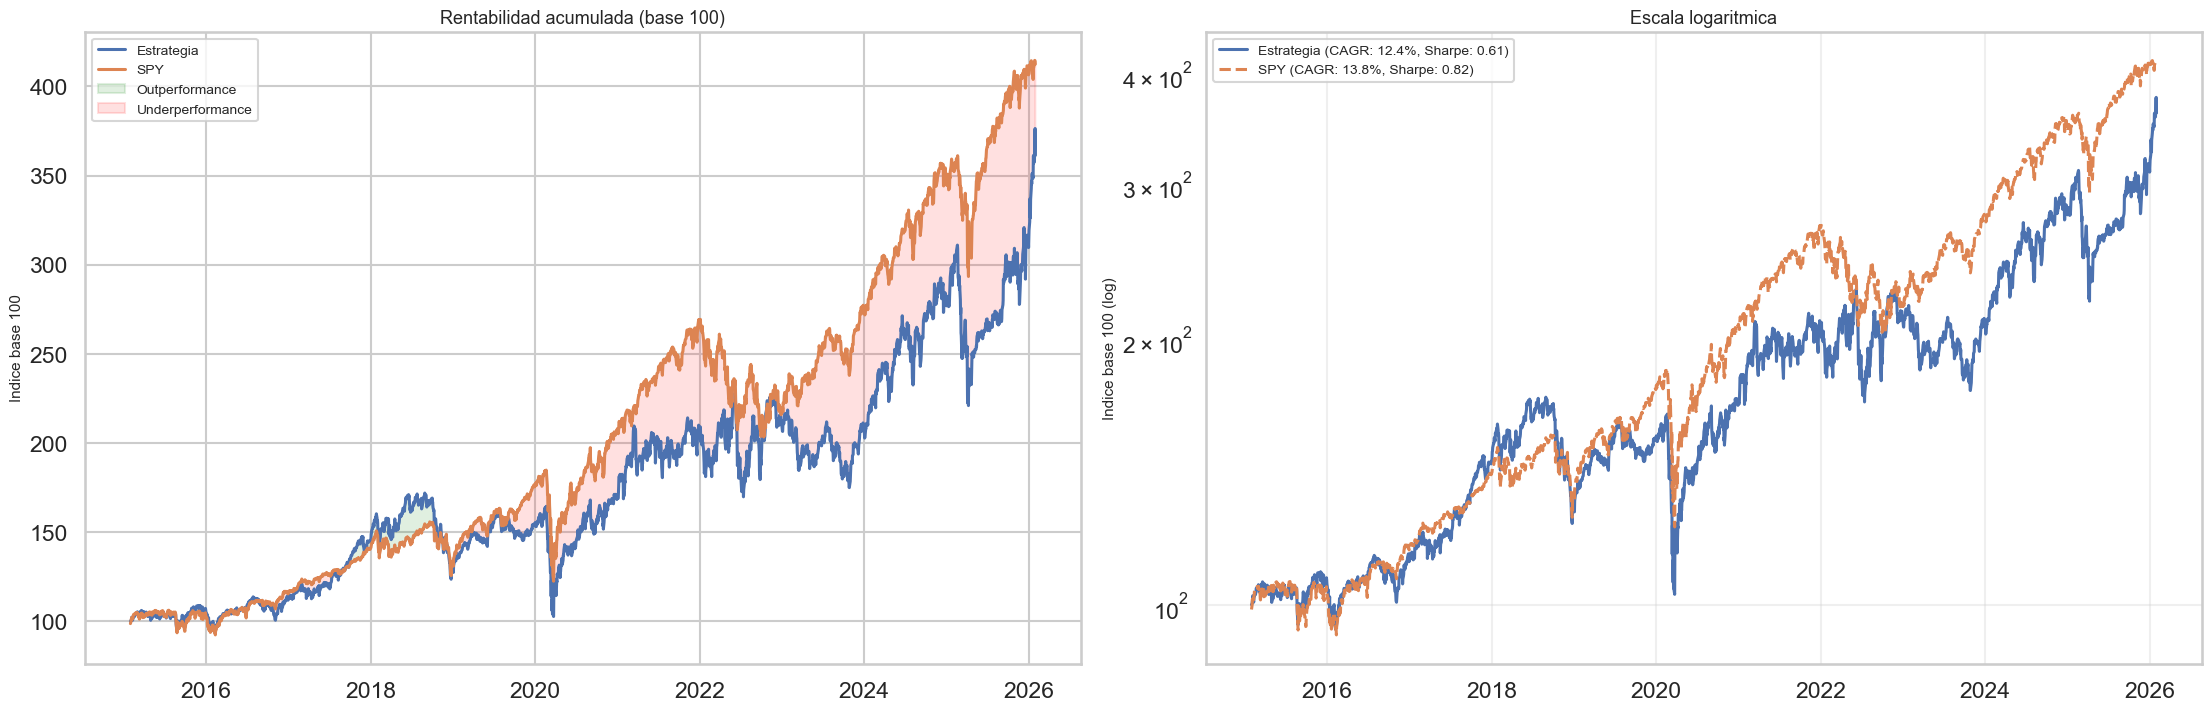

In [5]:
cagr_s = float(metrics.loc[metrics["metric"] == "CAGR", "strategy"].iloc[0])
cagr_b = float(metrics.loc[metrics["metric"] == "CAGR", "spy"].iloc[0])
sharpe_s = float(metrics.loc[metrics["metric"] == "Sharpe", "strategy"].iloc[0])
sharpe_b = float(metrics.loc[metrics["metric"] == "Sharpe", "spy"].iloc[0])

cum = (1 + returns_daily[["strategy", "spy"]]).cumprod() * 100
spread = cum["strategy"] - cum["spy"]

fig, axes = plt.subplots(1, 2, figsize=(22, 7), constrained_layout=True)

# Panel 1: escala lineal con sombreado
axes[0].plot(cum.index, cum["strategy"], label="Estrategia", linewidth=2.2)
axes[0].plot(cum.index, cum["spy"], label="SPY", linewidth=2.2)
axes[0].fill_between(cum.index, cum["strategy"], cum["spy"],
                     where=(spread >= 0).to_numpy(), color="green", alpha=0.12, label="Outperformance")
axes[0].fill_between(cum.index, cum["strategy"], cum["spy"],
                     where=(spread < 0).to_numpy(), color="red", alpha=0.12, label="Underperformance")
axes[0].set_title("Rentabilidad acumulada (base 100)")
axes[0].set_ylabel("Indice base 100")
axes[0].legend(loc="upper left", fontsize=10)

# Panel 2: escala logaritmica con metricas en leyenda
axes[1].plot(cum.index, cum["strategy"],
             label=f"Estrategia (CAGR: {cagr_s:.1%}, Sharpe: {sharpe_s:.2f})", linewidth=2.2)
axes[1].plot(cum.index, cum["spy"],
             label=f"SPY (CAGR: {cagr_b:.1%}, Sharpe: {sharpe_b:.2f})", linewidth=2.2, linestyle="--")
axes[1].set_yscale("log")
axes[1].set_title("Escala logaritmica")
axes[1].set_ylabel("Indice base 100 (log)")
axes[1].legend(loc="upper left", fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.show()



---

## 5. Distribuciones de retornos

El histograma mensual compara el perfil de dispersiones entre estrategia y SPY: colas m&aacute;s gruesas indican meses con movimientos extremos m&aacute;s frecuentes. El heatmap anual-mensual permite identificar visualmente si la estrategia tiene patrones estacionales o concentra su rendimiento en per&iacute;odos espec&iacute;ficos.

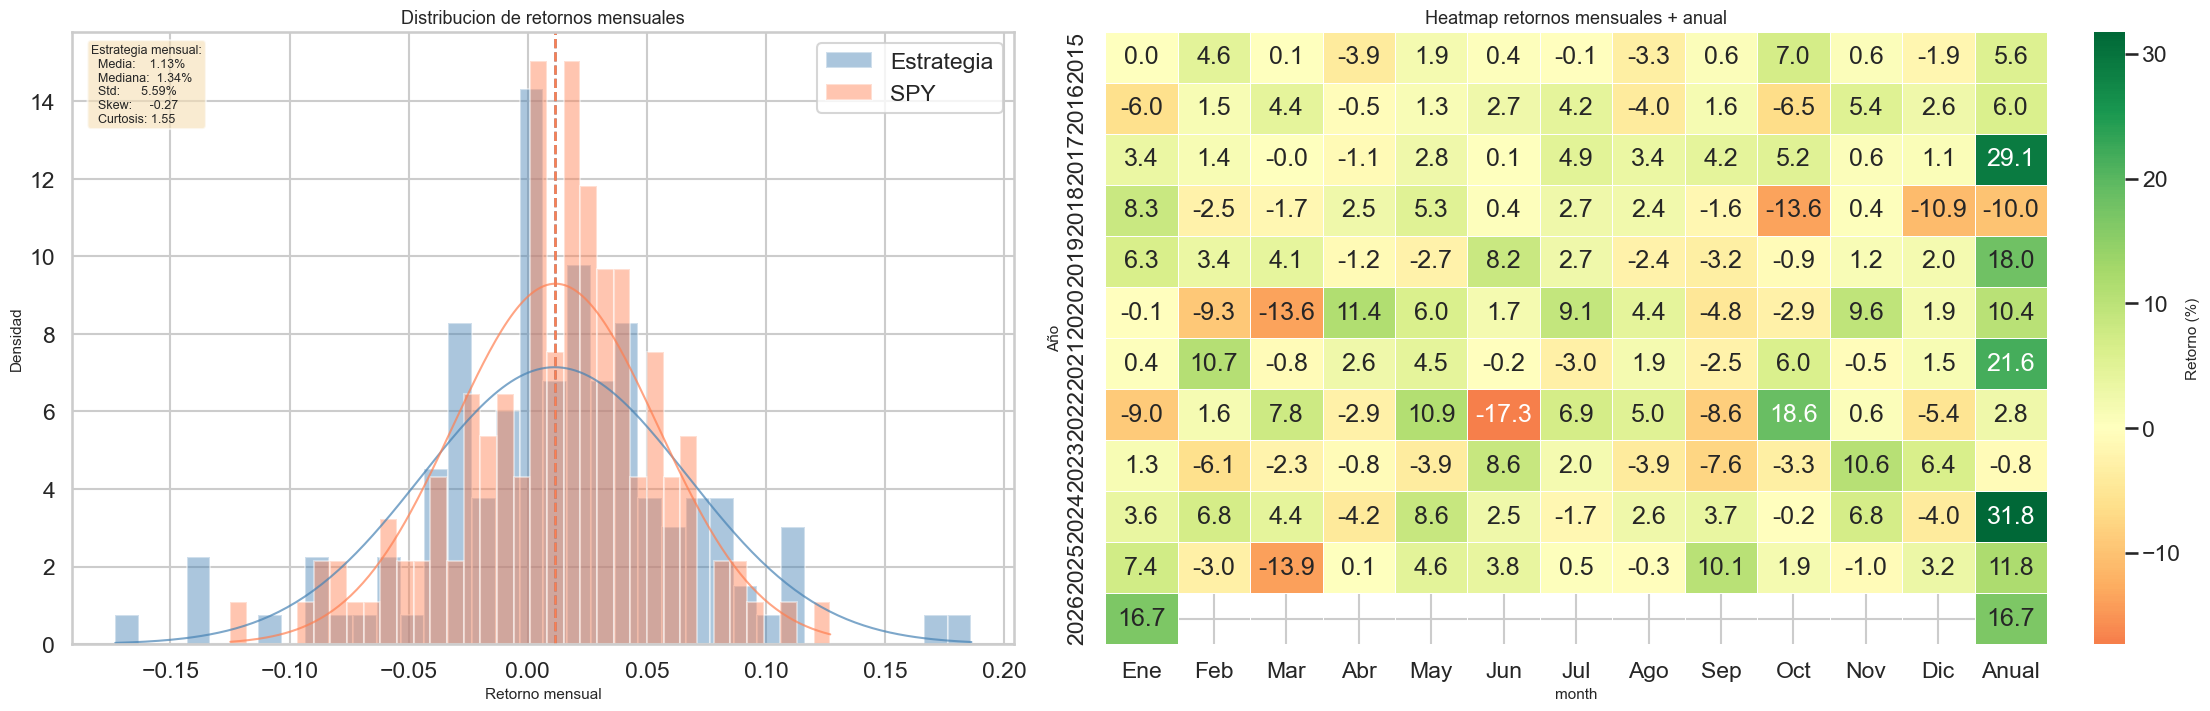

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7), constrained_layout=True)

# Panel 1: histograma mensual con curva normal
for col, color, label in [("strategy", "steelblue", "Estrategia"), ("spy", "coral", "SPY")]:
    ret = monthly_returns[col].dropna()
    axes[0].hist(ret, bins=36, density=True, alpha=0.45, color=color, edgecolor="white", label=label)
    axes[0].axvline(ret.mean(), color=color, linestyle="--", linewidth=1.8)
    # Curva normal superpuesta
    x = np.linspace(ret.min(), ret.max(), 200)
    axes[0].plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), color=color, linewidth=1.5, alpha=0.7)

# Textbox de stats
s_ret = monthly_returns["strategy"].dropna()
box_text = (f"Estrategia mensual:\n"
            f"  Media:    {s_ret.mean():.2%}\n"
            f"  Mediana:  {s_ret.median():.2%}\n"
            f"  Std:      {s_ret.std():.2%}\n"
            f"  Skew:     {s_ret.skew():.2f}\n"
            f"  Curtosis: {s_ret.kurtosis():.2f}")
axes[0].text(0.02, 0.98, box_text, transform=axes[0].transAxes, fontsize=9,
             va="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))
axes[0].set_title("Distribucion de retornos mensuales")
axes[0].set_xlabel("Retorno mensual")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Panel 2: heatmap con columna anual
heat = monthly_returns["strategy"].copy() * 100
heat_df = pd.DataFrame({"year": heat.index.year, "month": heat.index.month, "value": heat.values})
heat_pivot = heat_df.pivot(index="year", columns="month", values="value").reindex(columns=range(1, 13))

# Columna anual
annual_by_year = annual_returns["strategy"].copy() * 100
for yr in heat_pivot.index:
    mask = annual_by_year.index.year == yr
    heat_pivot.loc[yr, "Anual"] = float(annual_by_year[mask].values[0]) if mask.any() else np.nan

months = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic", "Anual"]
sns.heatmap(heat_pivot, cmap="RdYlGn", center=0, annot=True, fmt=".1f",
            linewidths=0.4, cbar_kws={"label": "Retorno (%)"}, ax=axes[1])
axes[1].set_title("Heatmap retornos mensuales + anual")
axes[1].set_xticklabels(months, rotation=0)
axes[1].set_ylabel("Año")
plt.show()

---

## 6. Scatter anual y trimestral

Los scatter plots comparan retornos peri&oacute;dicos de la estrategia frente al SPY. La l&iacute;nea de regresi&oacute;n captura la sensibilidad (beta), el $R^2$ mide la proporci&oacute;n de varianza explicada por el benchmark, y la l&iacute;nea de 45 grados indica retorno id&eacute;ntico. Puntos por encima de la diagonal representan per&iacute;odos de outperformance. Se incluyen ambas granularidades porque el scatter anual puede enga&ntilde;ar con pocas observaciones; el trimestral aporta m&aacute;s datos pero con mayor ruido.

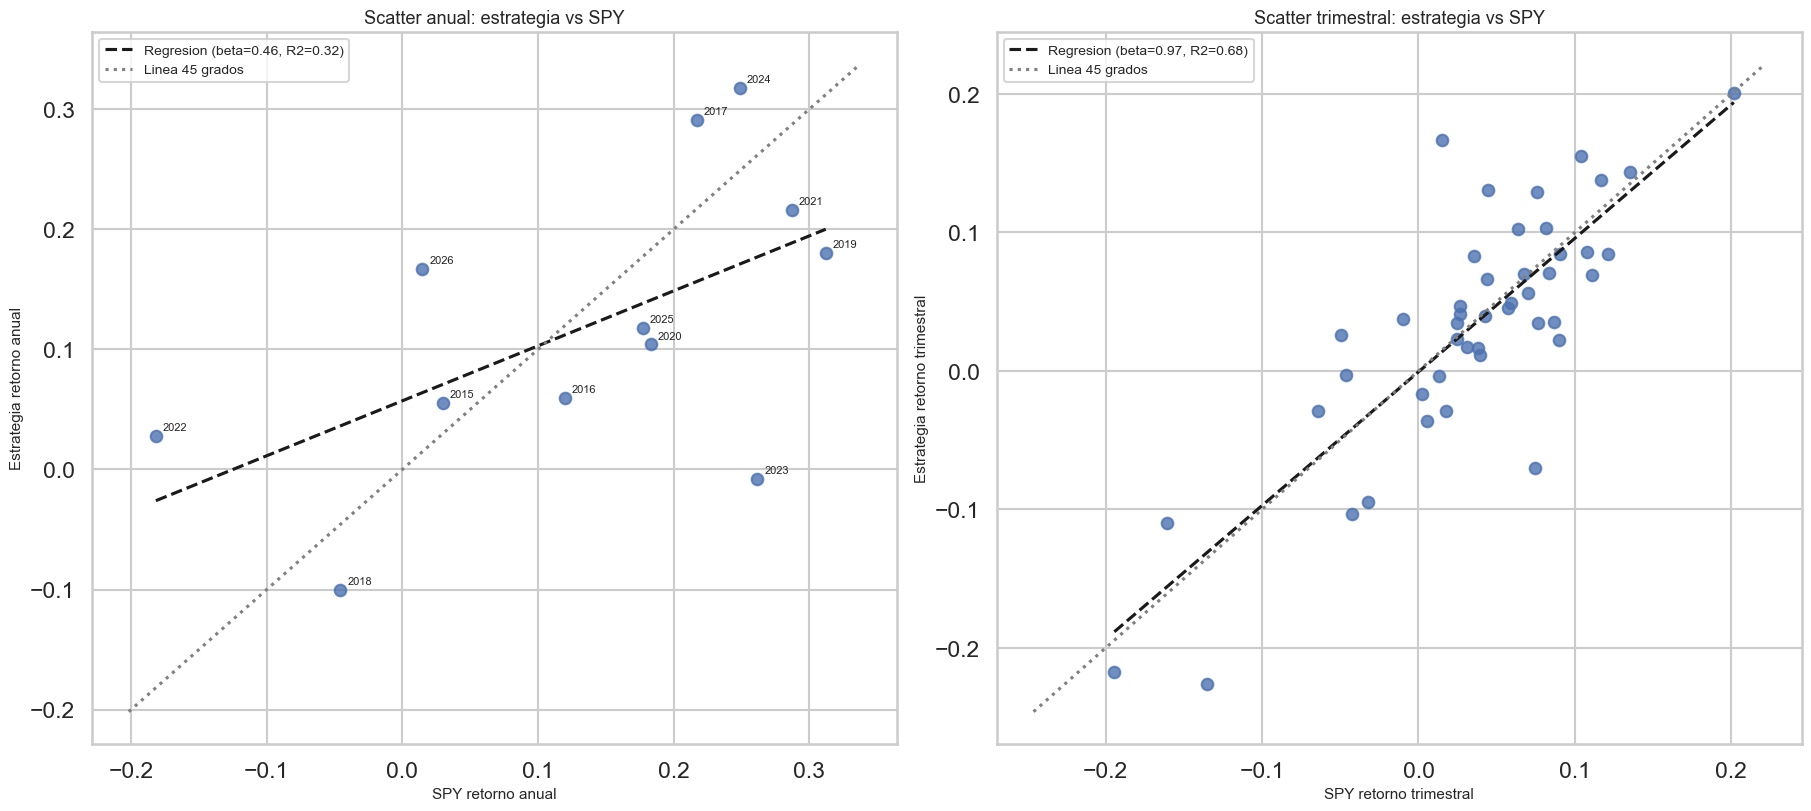

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

for ax, ret_df, freq in [
    (axes[0], annual_returns.dropna(), "anual"),
    (axes[1], quarterly_returns.dropna(), "trimestral"),
]:
    x = ret_df["spy"].to_numpy()
    y = ret_df["strategy"].to_numpy()
    reg = stats.linregress(x, y)
    r2 = reg.rvalue ** 2

    ax.scatter(x, y, s=70, alpha=0.8)
    xs = np.sort(x)
    ax.plot(xs, reg.intercept + reg.slope * xs, "k--",
            label=f"Regresion (beta={reg.slope:.2f}, R2={r2:.2f})")
    lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
    ax.plot(lims, lims, ":", color="gray", label="Linea 45 grados")
    ax.set_title(f"Scatter {freq}: estrategia vs SPY")
    ax.set_xlabel(f"SPY retorno {freq}")
    ax.set_ylabel(f"Estrategia retorno {freq}")
    ax.legend(fontsize=10)

    if freq == "anual":
        ret_df = ret_df.copy()
        ret_df["year"] = ret_df.index.year
        for _, row in ret_df.iterrows():
            ax.annotate(str(int(row["year"])), (row["spy"], row["strategy"]),
                        textcoords="offset points", xytext=(5, 4), fontsize=8)

plt.show()

---

## 7. Persistencia de reg&iacute;menes

La matriz de transici&oacute;n mide la probabilidad de que un mes positivo sea seguido por otro positivo (o negativo), y viceversa. Si la probabilidad en la diagonal es alta, existe inercia de r&eacute;gimen. La distribuci&oacute;n de rachas complementa esta visi&oacute;n mostrando cu&aacute;ntos meses consecutivos se mantiene el signo: rachas largas positivas sugieren momentum sostenido; rachas negativas largas indican per&iacute;odos de estr&eacute;s prolongado.

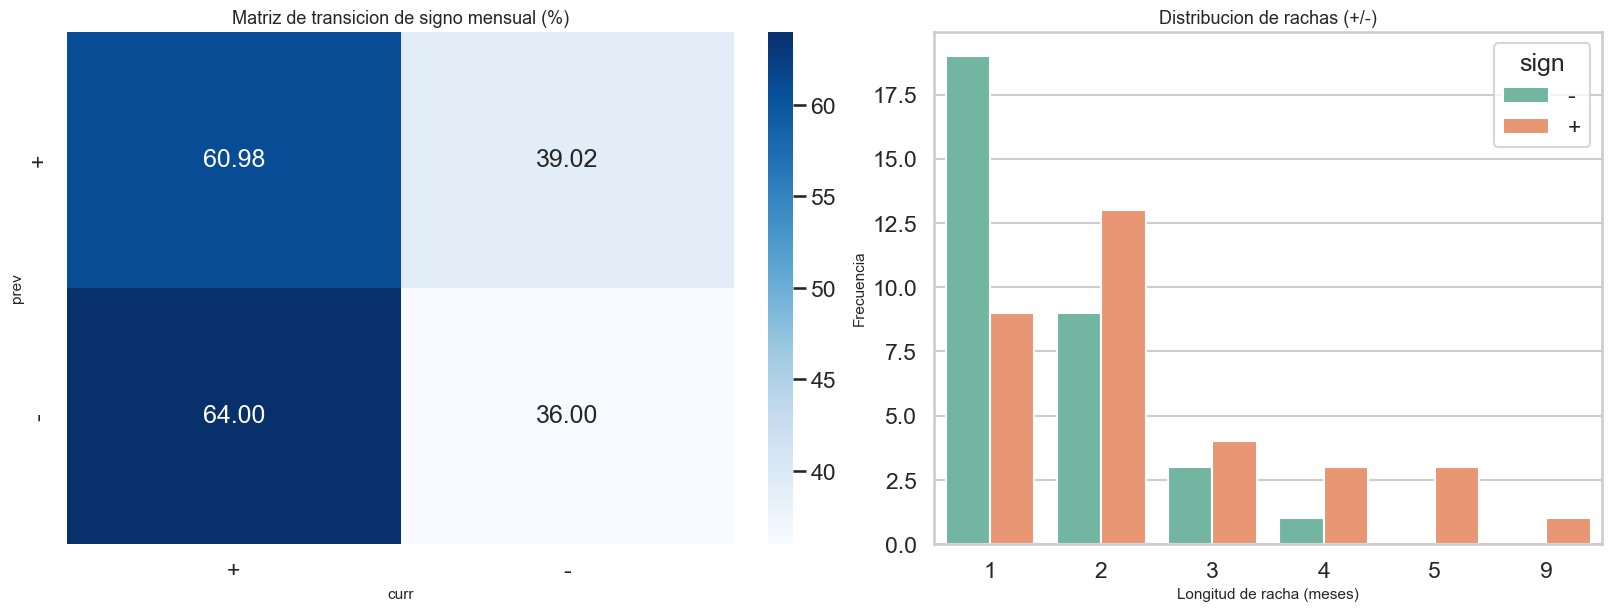

In [8]:
monthly_sign = np.where(monthly_returns["strategy"] >= 0, "+", "-")
trans_df = pd.DataFrame({"prev": pd.Series(monthly_sign).shift(1), "curr": monthly_sign}).dropna()
transition = pd.crosstab(trans_df["prev"], trans_df["curr"], normalize="index") * 100

sign_series = pd.Series(monthly_sign, index=monthly_returns.index)
groups = (sign_series != sign_series.shift(1)).cumsum()
streak_df = pd.DataFrame({
    "sign": sign_series.groupby(groups).first().values,
    "length": sign_series.groupby(groups).size().values,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
sns.heatmap(transition, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de transicion de signo mensual (%)")

sns.countplot(data=streak_df, x="length", hue="sign", ax=axes[1], palette="Set2")
axes[1].set_title("Distribucion de rachas (+/-)")
axes[1].set_xlabel("Longitud de racha (meses)")
axes[1].set_ylabel("Frecuencia")
plt.show()

---

## 8. Riesgo din&aacute;mico

Tres paneles complementarios muestran la evoluci&oacute;n temporal del riesgo. El **drawdown** compara la profundidad de las ca&iacute;das entre estrategia y SPY: un drawdown m&aacute;s pronunciado implica mayor riesgo de ruina percibida. El **rolling Sharpe** (ventana de 126 d&iacute;as, ~6 meses) muestra si la eficiencia riesgo-retorno es estable o c&iacute;clica. El **rolling beta** mide c&oacute;mo var&iacute;a la exposici&oacute;n al mercado en el tiempo: un beta que oscila mucho sugiere que la estrategia cambia de car&aacute;cter en distintos reg&iacute;menes.

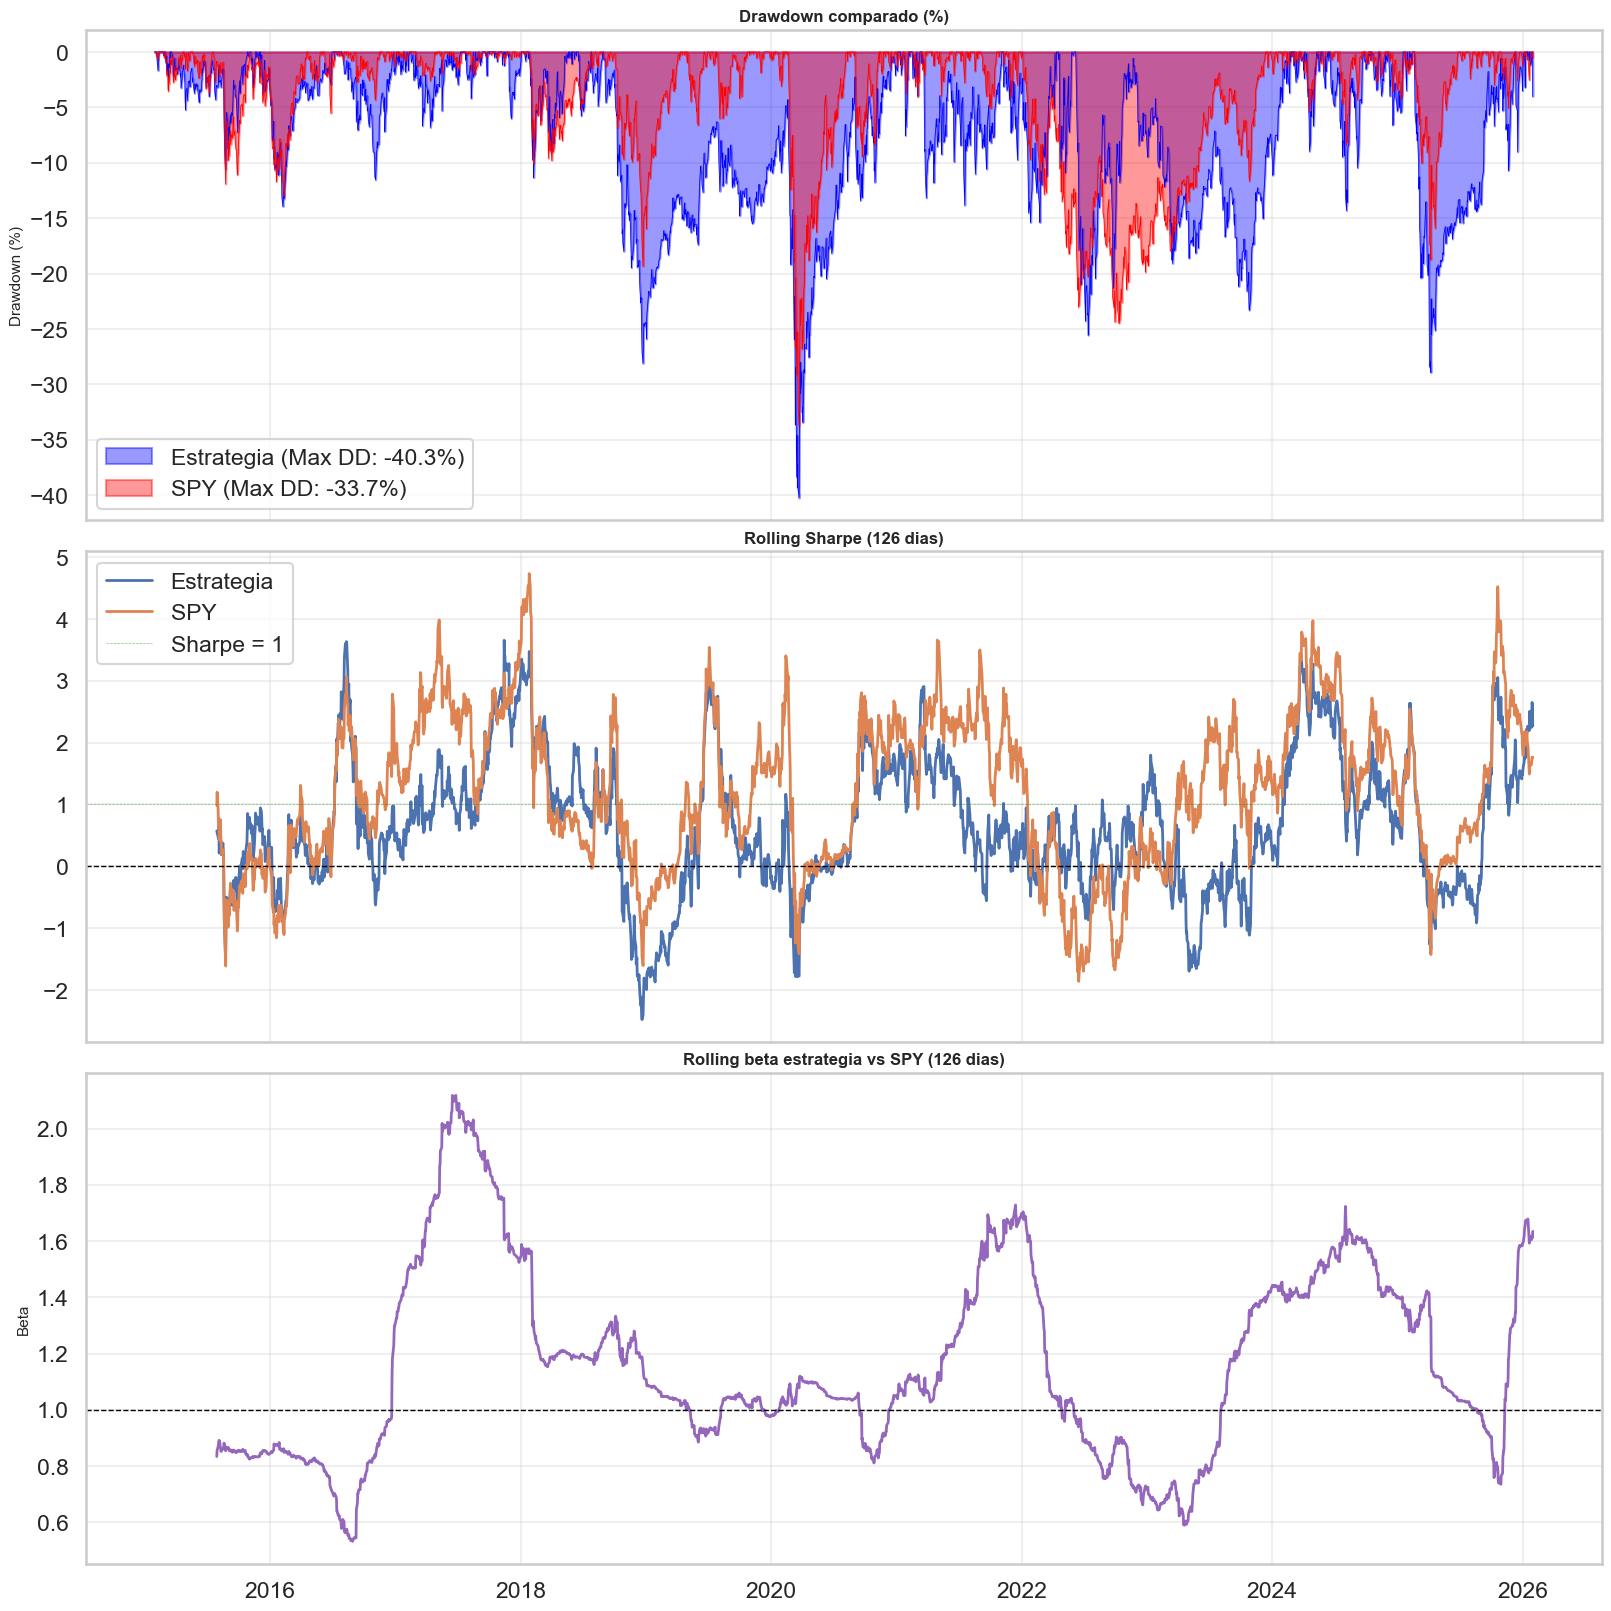

In [9]:
mdd_s = float(metrics.loc[metrics["metric"] == "Max Drawdown", "strategy"].iloc[0])
mdd_b = float(metrics.loc[metrics["metric"] == "Max Drawdown", "spy"].iloc[0])

wealth = (1 + returns_daily[["strategy", "spy"]]).cumprod()
dd = wealth / wealth.cummax() - 1

win = 126
roll_mu = returns_daily[["strategy", "spy"]].rolling(win).mean()
roll_std = returns_daily[["strategy", "spy"]].rolling(win).std(ddof=1)
roll_sharpe = np.sqrt(TRADING_DAYS) * ((roll_mu - RF_DAILY) / roll_std)

roll_beta = (
    returns_daily["strategy"].rolling(win).cov(returns_daily["spy"])
    / returns_daily["spy"].rolling(win).var()
)

fig, axes = plt.subplots(3, 1, figsize=(16, 16), sharex=True, constrained_layout=True)

axes[0].fill_between(dd.index, dd["strategy"] * 100, 0, alpha=0.4, color="blue",
                     label=f"Estrategia (Max DD: {mdd_s:.1%})")
axes[0].fill_between(dd.index, dd["spy"] * 100, 0, alpha=0.4, color="red",
                     label=f"SPY (Max DD: {mdd_b:.1%})")
axes[0].plot(dd.index, dd["strategy"] * 100, color="blue", linewidth=0.5)
axes[0].plot(dd.index, dd["spy"] * 100, color="red", linewidth=0.5)
axes[0].set_title("Drawdown comparado (%)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Drawdown (%)")
axes[0].legend(loc="lower left")
axes[0].grid(True, alpha=0.3)

axes[1].plot(roll_sharpe.index, roll_sharpe["strategy"], label="Estrategia", linewidth=2)
axes[1].plot(roll_sharpe.index, roll_sharpe["spy"], label="SPY", linewidth=2)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(1, color="green", linestyle="--", linewidth=0.5, alpha=0.5, label="Sharpe = 1")
axes[1].set_title("Rolling Sharpe (126 dias)", fontsize=12, fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(roll_beta.index, roll_beta, color="tab:purple", linewidth=2)
axes[2].axhline(1, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Rolling beta estrategia vs SPY (126 dias)", fontsize=12, fontweight="bold")
axes[2].set_ylabel("Beta")
axes[2].grid(True, alpha=0.3)

plt.show()



---

## 9. Diagn&oacute;stico operativo y an&aacute;lisis de comisiones

Este bloque traduce las fricciones de ejecuci&oacute;n a impacto econ&oacute;mico medible. Para mejorar legibilidad, se muestran solo dos visualizaciones: **(1)** salidas forzosas con precio proxy sobre la curva de equity y **(2)** comisi&oacute;n total por tipo de orden con etiquetas de negocio legibles.

Adem&aacute;s, se sustituye el detalle textual por una tabla `pandas` estilizada con m&eacute;tricas operativas y de comisiones: comisi&oacute;n total, media/mediana/m&iacute;nimo/m&aacute;ximo por operaci&oacute;n, impacto de la comisi&oacute;n m&iacute;nima, incidencias `no_fill_cash` y faltantes de caja asociados.

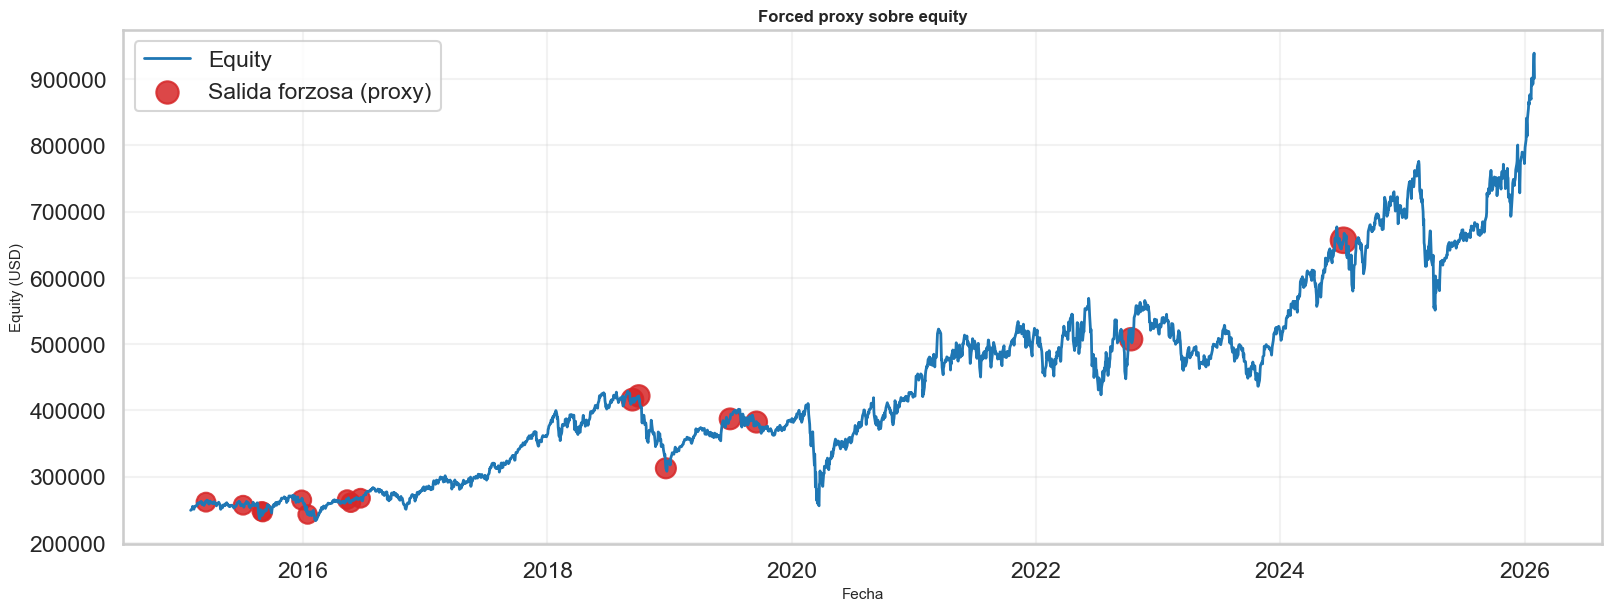

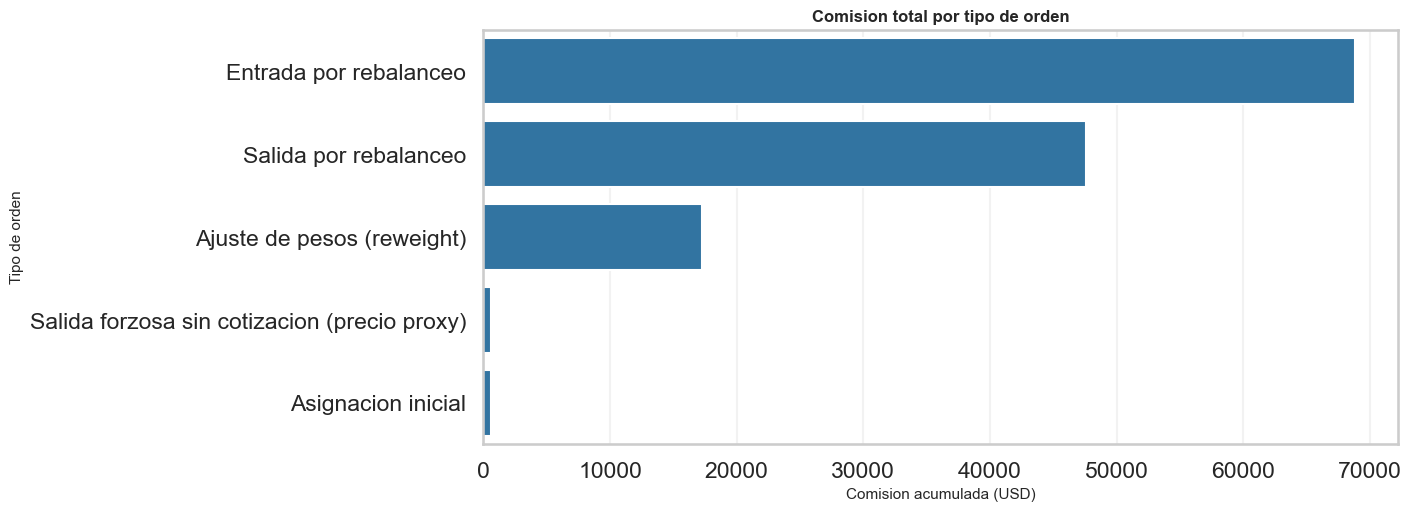

Metrica,Valor
Ordenes ejecutadas con comision,"3,594"
Comision total,"$134,828.27"
Comision / capital inicial,53.93%
Comision / equity final,14.96%
Comision media por operacion,$37.51
Comision mediana por operacion,$29.79
Comision minima por operacion,$23.00
Comision maxima por operacion,$122.05
Ordenes afectadas por comision minima,"1,632"
% de ordenes con comision minima,45.41%


In [10]:
# --- Excepciones de ejecucion y costes observados ---
cols_no_fill = ["date", "symbol", "reason", "price", "cash_before", "cash_after", "required_cash_at_close", "cash_gap_close"]
cols_no_fill = [c for c in cols_no_fill if c in orders.columns]
no_fill_cash_df = (
    orders.loc[orders["status"] == "no_fill_cash", cols_no_fill]
    .copy()
    .sort_values(["date", "symbol"])
)

if {"required_cash_at_close", "cash_before"}.issubset(no_fill_cash_df.columns):
    no_fill_cash_df["cash_shortfall"] = (
        pd.to_numeric(no_fill_cash_df["required_cash_at_close"], errors="coerce")
        - pd.to_numeric(no_fill_cash_df["cash_before"], errors="coerce")
    ).clip(lower=0)
elif "cash_gap_close" in no_fill_cash_df.columns:
    no_fill_cash_df["cash_shortfall"] = pd.to_numeric(no_fill_cash_df["cash_gap_close"], errors="coerce").clip(lower=0)
else:
    no_fill_cash_df["cash_shortfall"] = np.nan

forced_proxy_df = orders.loc[
    (orders["reason"] == "forced_exit_no_quote_proxy") & (orders["status"] == "filled"),
    ["date", "symbol", "price", "fee", "proxy_price_date"],
].copy().sort_values(["date", "symbol"])

# Tabla proxy de tension mensual de caja para incidencias no_fill_cash.
reb = rebalance_summary.copy().sort_values("date")
if "n_rebalance_entry_no_fill_cash" not in reb.columns:
    reb["n_rebalance_entry_no_fill_cash"] = 0
reb["required_cash_proxy"] = reb["equity"] * 0.05 * reb["n_rebalance_entry_no_fill_cash"]
reb["deficit_proxy"] = np.clip(reb["required_cash_proxy"] - reb["cash"], 0, None)
reb_tension = reb.loc[reb["n_rebalance_entry_no_fill_cash"] > 0].copy()

# --- Comisiones ---
filled = orders.loc[(orders["status"] == "filled") & (orders["notional"].abs() > 0)].copy()
filled["min_fee_hit"] = (filled["notional"].abs() * fee_rate) < fee_min
filled["extra_min"] = np.where(filled["min_fee_hit"], fee_min - filled["notional"].abs() * fee_rate, 0.0)

reason_labels = {
    "initial_allocation": "Asignacion inicial",
    "rebalance_entry": "Entrada por rebalanceo",
    "rebalance_exit": "Salida por rebalanceo",
    "rebalance_reweight": "Ajuste de pesos (reweight)",
    "forced_exit_no_quote_proxy": "Salida forzosa sin cotizacion (precio proxy)",
}

fee_reason = (
    filled.groupby("reason", as_index=False)["fee"]
    .sum()
    .sort_values("fee", ascending=False)
)
fee_reason["tipo_orden"] = fee_reason["reason"].map(reason_labels).fillna(
    fee_reason["reason"].str.replace("_", " ", regex=False).str.title()
)

# --- Visual 1: forced proxy sobre equity ---
fig, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)
ax.plot(portfolio_daily["date"], portfolio_daily["equity"], color="tab:blue", linewidth=2, label="Equity")

if len(forced_proxy_df) > 0:
    fp = forced_proxy_df.groupby("date", as_index=False).agg(fee=("fee", "sum"))
    eq_map = portfolio_daily.set_index("date")["equity"]
    fp["equity"] = fp["date"].map(eq_map)
    fp = fp.dropna(subset=["equity"])

    if len(fp) > 0:
        fee_max = float(fp["fee"].max())
        if fee_max > 0:
            sizes = 80 + (fp["fee"] / fee_max) * 260
        else:
            sizes = np.full(len(fp), 120.0)
        ax.scatter(fp["date"], fp["equity"], color="tab:red", s=sizes, alpha=0.85, label="Salida forzosa (proxy)")

ax.set_title("Forced proxy sobre equity", fontsize=12, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Equity (USD)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.25)
plt.show()

# --- Visual 2: comision total por tipo de orden ---
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
sns.barplot(data=fee_reason, x="fee", y="tipo_orden", orient="h", ax=ax, color="tab:blue")
ax.set_title("Comision total por tipo de orden", fontsize=12, fontweight="bold")
ax.set_xlabel("Comision acumulada (USD)")
ax.set_ylabel("Tipo de orden")
ax.grid(True, axis="x", alpha=0.25)
plt.show()

# --- Tabla de metricas operativas y de comisiones ---
def _fmt_money(x):
    return "N/A" if pd.isna(x) else f"${x:,.2f}"


def _fmt_int(x):
    return "N/A" if pd.isna(x) else f"{int(x):,}"


def _fmt_pct(x):
    return "N/A" if pd.isna(x) else f"{100 * x:.2f}%"


total_fee = float(cost_summary["total_fee"].iloc[0])
init_cap = float(cost_summary["initial_capital"].iloc[0])
final_eq = float(cost_summary["final_equity"].iloc[0])

filled_fee = pd.to_numeric(filled["fee"], errors="coerce")
extra_min = pd.to_numeric(filled["extra_min"], errors="coerce")
min_hit_mask = filled["min_fee_hit"].fillna(False)

cash_shortfall = pd.to_numeric(no_fill_cash_df["cash_shortfall"], errors="coerce")
deficit_proxy = pd.to_numeric(reb_tension["deficit_proxy"], errors="coerce") if len(reb_tension) > 0 else pd.Series(dtype=float)

ops_metrics = pd.DataFrame(
    [
        {"Metrica": "Ordenes ejecutadas con comision", "Valor": _fmt_int(len(filled))},
        {"Metrica": "Comision total", "Valor": _fmt_money(total_fee)},
        {"Metrica": "Comision / capital inicial", "Valor": _fmt_pct(total_fee / init_cap if init_cap > 0 else np.nan)},
        {"Metrica": "Comision / equity final", "Valor": _fmt_pct(total_fee / final_eq if final_eq > 0 else np.nan)},
        {"Metrica": "Comision media por operacion", "Valor": _fmt_money(filled_fee.mean())},
        {"Metrica": "Comision mediana por operacion", "Valor": _fmt_money(filled_fee.median())},
        {"Metrica": "Comision minima por operacion", "Valor": _fmt_money(filled_fee.min())},
        {"Metrica": "Comision maxima por operacion", "Valor": _fmt_money(filled_fee.max())},
        {"Metrica": "Ordenes afectadas por comision minima", "Valor": _fmt_int(min_hit_mask.sum())},
        {
            "Metrica": "% de ordenes con comision minima",
            "Valor": _fmt_pct(min_hit_mask.mean() if len(min_hit_mask) > 0 else np.nan),
        },
        {"Metrica": "Sobrecoste total por comision minima", "Valor": _fmt_money(extra_min.sum())},
        {
            "Metrica": "Sobrecoste medio (solo ordenes con minimo)",
            "Valor": _fmt_money(extra_min[min_hit_mask].mean() if min_hit_mask.any() else np.nan),
        },
        {"Metrica": "Ordenes no_fill_cash", "Valor": _fmt_int(len(no_fill_cash_df))},
        {
            "Metrica": "Fechas afectadas por no_fill_cash",
            "Valor": _fmt_int(no_fill_cash_df["date"].nunique() if "date" in no_fill_cash_df.columns else np.nan),
        },
        {
            "Metrica": "Faltante de caja mediano (no_fill_cash, por orden)",
            "Valor": _fmt_money(cash_shortfall.median()),
        },
        {
            "Metrica": "Faltante de caja maximo (no_fill_cash, por orden)",
            "Valor": _fmt_money(cash_shortfall.max()),
        },
        {
            "Metrica": "Faltante de caja mediano (proxy mensual)",
            "Valor": _fmt_money(deficit_proxy.median() if len(deficit_proxy) > 0 else np.nan),
        },
        {"Metrica": "Salidas forzosas con proxy", "Valor": _fmt_int(len(forced_proxy_df))},
        {
            "Metrica": "Comision total en salidas forzosas (proxy)",
            "Valor": _fmt_money(pd.to_numeric(forced_proxy_df["fee"], errors="coerce").sum() if len(forced_proxy_df) > 0 else 0.0),
        },
    ]
)

display(
    ops_metrics.style.hide(axis="index")
    .set_caption("Resumen operativo y analisis de comisiones")
    .set_properties(subset=["Metrica", "Valor"], **{"text-align": "left"})
)

---

## 10. Monte Carlo directo (25M carteras)

Este es el test de robustez principal del enunciado. Se simulan 25 millones de carteras aleatorias de 20 activos, con muestreo **sin reemplazo** en cada mes del universo elegible. El objetivo es comparar la estrategia real frente a una distribuci&oacute;n de resultados por azar bajo las mismas condiciones de mercado.

Caracter&iacute;sticas del dise&ntilde;o:
- **No param&eacute;trico**: se usan retornos forward observados (no supuestos normales).
- **Sin reemplazo intra-cartera**: cada mono selecciona 20 activos distintos por mes.
- **Coste operativo aplicado**: coste mensual equivalente a compra+venta (`2 * fee_rate`).
- **Misma ventana operativa que N4**: se alinea la fecha inicial y el tramo mensual para comparar magnitudes homog&eacute;neas.

M&eacute;tricas reportadas:
- percentil de la estrategia en la distribuci&oacute;n de monos,
- probabilidad `P(monkey > estrategia)`,
- cuantiles de la distribuci&oacute;n final,
- tiempo total de ejecuci&oacute;n y validaci&oacute;n `<24h`.

In [11]:
strategy_final_equity = float(cost_summary["final_equity"].iloc[0])
initial_capital = float(cost_summary["initial_capital"].iloc[0])
strategy_return_vs_initial_capital = float(cost_summary["return_vs_initial_capital"].iloc[0])
strategy_return_from_first_valuation = float(cost_summary["return_from_first_valuation"].iloc[0])

# ================================================================
# 11A. Preparacion del universo mensual para Monte Carlo directo
# ================================================================
sig_mc = signals_input[["rebalance_date", "symbol", "eligible_for_signals", "close_rebalance"]].copy()
sig_mc["rebalance_date"] = pd.to_datetime(sig_mc["rebalance_date"])
sig_mc = sig_mc.sort_values(["symbol", "rebalance_date"]).reset_index(drop=True)

# Retorno forward mensual por simbolo (t -> t+1)
sig_mc["close_next"] = sig_mc.groupby("symbol", observed=True)["close_rebalance"].shift(-1)
sig_mc["fwd_ret"] = sig_mc["close_next"] / sig_mc["close_rebalance"] - 1

# Fechas realmente operadas en N4 + fecha inicial para alinear horizonte.
# Ojo: la primera fecha es la construccion inicial de cartera (no un rebalanceo mensual).
initial_mc_rows = portfolio_daily.loc[portfolio_daily["is_initial_allocation"] == True, "date"]
fail_if(len(initial_mc_rows) == 0, "No se encontro fecha inicial en portfolio_daily")
initial_mc_date = pd.Timestamp(initial_mc_rows.drop_duplicates().sort_values().iloc[0])

signal_months = pd.Index(
    pd.concat([pd.Series([initial_mc_date]), rebalance_summary["date"]], ignore_index=True)
    .drop_duplicates()
    .sort_values()
)

mc_universe = sig_mc.loc[
    sig_mc["rebalance_date"].isin(signal_months)
    & (sig_mc["eligible_for_signals"] == True)
    & np.isfinite(sig_mc["fwd_ret"])
    & (sig_mc["fwd_ret"] > -0.999),
    ["rebalance_date", "symbol", "fwd_ret"],
].copy()

month_groups = []
month_meta_rows = []
for dt, grp in mc_universe.groupby("rebalance_date", observed=True):
    dt = pd.Timestamp(dt)
    arr = grp["fwd_ret"].to_numpy(dtype=np.float32)
    if len(arr) >= MONKEY_K:
        month_groups.append((dt, arr))
        month_meta_rows.append(
            {
                "operating_date": dt,
                "period_type": "Construccion inicial" if dt == initial_mc_date else "Rebalanceo mensual",
                "n_assets": int(len(arr)),
                "mean_fwd_ret": float(arr.mean()),
                "std_fwd_ret": float(arr.std(ddof=1)) if len(arr) > 1 else np.nan,
            }
        )

fail_if(len(month_groups) == 0, "No hay meses validos para Monte Carlo")

month_meta_df = pd.DataFrame(month_meta_rows).sort_values("operating_date").reset_index(drop=True)
mc_n_months = int(len(month_groups))
mc_month_start = month_meta_df["operating_date"].min().date()
mc_month_end = month_meta_df["operating_date"].max().date()

print("Universo Monte Carlo preparado")
print(f"  Meses validos:           {mc_n_months}")
print(
    f"  Activos/mes min-med-max: {int(month_meta_df['n_assets'].min())}-"
    f"{int(month_meta_df['n_assets'].median())}-"
    f"{int(month_meta_df['n_assets'].max())}"
)
print(f"  Monos declarados:        {N_MONKEYS:,}")
print(f"  Lotes por mes:           {int(np.ceil(N_MONKEYS / MONKEY_BATCH))}")
print(f"  Return vs capital (N4):  {strategy_return_vs_initial_capital:.2%}")
print(f"  Ventana MC (meses t):    {mc_month_start} -> {mc_month_end}")

month_meta_show = month_meta_df.rename(
    columns={
        "operating_date": "fecha_operativa",
        "period_type": "tipo_periodo",
        "n_assets": "n_activos",
        "mean_fwd_ret": "ret_forward_medio",
        "std_fwd_ret": "ret_forward_std",
    }
).copy()

display(month_meta_show.head(8))

Universo Monte Carlo preparado
  Meses validos:           132
  Activos/mes min-med-max: 459-478-484
  Monos declarados:        25,000,000
  Lotes por mes:           100
  Return vs capital (N4):  260.53%
  Ventana MC (meses t):    2015-01-30 -> 2025-12-31


,fecha_operativa,tipo_periodo,n_activos,ret_forward_medio,ret_forward_std
0,2015-01-30,Construccion inicial,480,0.057724,0.070270
1,2015-02-27,Rebalanceo mensual,481,-0.010054,0.051952
2,2015-03-31,Rebalanceo mensual,479,0.005239,0.068275
3,2015-04-30,Rebalanceo mensual,478,0.008115,0.058337
4,2015-05-29,Rebalanceo mensual,477,-0.022463,0.052128
5,2015-06-30,Rebalanceo mensual,475,0.006953,0.084175
6,2015-07-31,Rebalanceo mensual,471,-0.054000,0.058285
7,2015-08-31,Rebalanceo mensual,472,-0.031777,0.070337


In [12]:
# ================================================================
# 11B. Ejecucion Monte Carlo directo (no parametrico) por lotes
# ================================================================
def _to_date_safe(x):
    dt = pd.to_datetime(x, errors="coerce")
    return dt.date() if pd.notna(dt) else None

cache_ready = (
    pd.io.common.file_exists(MC_DIRECT_WEALTH_NPY)
    and pd.io.common.file_exists(MC_DIRECT_SUMMARY_CSV)
)
cache_valid = False
cache_reason = ""

if (not FORCE_RECOMPUTE_MONKEYS) and cache_ready:
    try:
        direct_cache = pd.read_csv(MC_DIRECT_SUMMARY_CSV)
        fail_if(direct_cache.empty, "Resumen de cache vacio")
        row = direct_cache.iloc[0]

        checks = {
            "n_monkeys": int(row.get("n_monkeys", -1)) == N_MONKEYS,
            "seed": int(row.get("seed", -1)) == MONKEY_SEED,
            "monkey_k": int(row.get("monkey_k", -1)) == MONKEY_K,
            "monkey_cost": np.isclose(float(row.get("monkey_cost", np.nan)), MONKEY_COST, atol=1e-12, rtol=0.0),
            "initial_capital": np.isclose(float(row.get("initial_capital", np.nan)), initial_capital, atol=1e-6, rtol=0.0),
            "mc_n_months": int(row.get("mc_n_months", -1)) == mc_n_months,
            "mc_month_start": _to_date_safe(row.get("mc_month_start", "")) == mc_month_start,
            "mc_month_end": _to_date_safe(row.get("mc_month_end", "")) == mc_month_end,
        }

        monkey_wealth = np.load(MC_DIRECT_WEALTH_NPY).astype(np.float32, copy=False)
        checks["wealth_len"] = len(monkey_wealth) == N_MONKEYS

        cache_valid = all(checks.values())
        if cache_valid:
            direct_elapsed = float(row.get("runtime_sec", np.nan))
            mc_start = pd.to_datetime(row.get("mc_start_utc", ""), utc=True, errors="coerce")
            mc_end = pd.to_datetime(row.get("mc_end_utc", ""), utc=True, errors="coerce")
            rng = np.random.default_rng(MONKEY_SEED)
            print(f"Monte Carlo directo cargado desde cache validada: {MC_DIRECT_WEALTH_NPY}")
        else:
            cache_reason = ", ".join([k for k, v in checks.items() if not v])

    except Exception as e:
        cache_reason = f"error al validar cache ({e})"

if FORCE_RECOMPUTE_MONKEYS or (not cache_valid):
    if cache_reason:
        print(f"Cache MC invalida, se recomputa: {cache_reason}")

    rng = np.random.default_rng(MONKEY_SEED)
    log_growth = np.zeros(N_MONKEYS, dtype=np.float32)

    mc_start = pd.Timestamp.now(tz="UTC")
    t0 = time.perf_counter()

    for m_idx, (month_dt, month_ret) in enumerate(month_groups, start=1):
        n_assets = month_ret.size
        start = 0

        while start < N_MONKEYS:
            batch = min(MONKEY_BATCH, N_MONKEYS - start)

            # Seleccion aleatoria sin reemplazo por mono
            idx = sample_no_replace(rng, batch, n_assets, MONKEY_K)

            # Retorno neto mensual: media equiponderada de K activos + coste multiplicativo
            gross = month_ret[idx].mean(axis=1, dtype=np.float32)
            sampled = (1.0 + gross) * (1.0 - MONKEY_COST) - 1.0
            sampled = np.clip(sampled, -0.95, None)

            # Acumulacion en log-wealth para estabilidad numerica
            log_growth[start:start + batch] += np.log1p(sampled).astype(np.float32)
            start += batch

        if m_idx == 1 or m_idx % 12 == 0 or m_idx == len(month_groups):
            elapsed = time.perf_counter() - t0
            eta = ((elapsed / m_idx) * (len(month_groups) - m_idx)) / 60
            print(
                f"  Mes {m_idx:03d}/{len(month_groups)} | {month_dt.date()} | "
                f"{elapsed/60:.1f} min | ETA {eta:.1f} min"
            )

    direct_elapsed = time.perf_counter() - t0
    mc_end = pd.Timestamp.now(tz="UTC")

    monkey_wealth = (initial_capital * np.exp(log_growth.astype(np.float64))).astype(np.float32)
    np.save(MC_DIRECT_WEALTH_NPY, monkey_wealth)

    print(f"\nMonte Carlo directo recalculado en {direct_elapsed/60:.1f} minutos.")
    print(f"Cache guardada en: {MC_DIRECT_WEALTH_NPY}")



  Mes 001/132 | 2015-01-30 | 0.5 min | ETA 62.5 min
  Mes 012/132 | 2015-12-31 | 5.7 min | ETA 57.0 min
  Mes 024/132 | 2016-12-30 | 11.4 min | ETA 51.5 min
  Mes 036/132 | 2017-12-29 | 17.4 min | ETA 46.3 min
  Mes 048/132 | 2018-12-31 | 23.3 min | ETA 40.7 min
  Mes 060/132 | 2019-12-31 | 29.1 min | ETA 34.9 min
  Mes 072/132 | 2020-12-31 | 34.8 min | ETA 29.0 min
  Mes 084/132 | 2021-12-31 | 40.8 min | ETA 23.3 min
  Mes 096/132 | 2022-12-30 | 46.6 min | ETA 17.5 min
  Mes 108/132 | 2023-12-29 | 52.3 min | ETA 11.6 min
  Mes 120/132 | 2024-12-31 | 58.0 min | ETA 5.8 min
  Mes 132/132 | 2025-12-31 | 63.6 min | ETA 0.0 min

Monte Carlo directo recalculado en 63.6 minutos.
Cache guardada en: data/processed/n5_mc_direct_wealth.npy


,n_monkeys,seed,monkey_k,monkey_cost,initial_capital,mc_n_months,mc_month_start,mc_month_end,sampling,model,...,strategy_final_equity,strategy_return_vs_initial_capital,strategy_return_from_first_valuation,strategy_percentile,p_monkey_beats_strategy,p05,p50,p95,ci95_low,ci95_high
0,25000000,42,20,0.0046,250000.0,132,2015-01-30,2025-12-31,without_replacement,direct_non_parametric,...,901325.726472,2.605303,2.613472,99.986152,0.000138,316386.310937,432372.53125,595859.1375,298118.528125,634917.751562


,q01,q05,q10,q25,q50,q75,q90,q95,q99
0,278251.75,316386.310937,338885.71875,380211.15625,432372.53125,492354.09375,554347.5,595859.1375,684090.3125


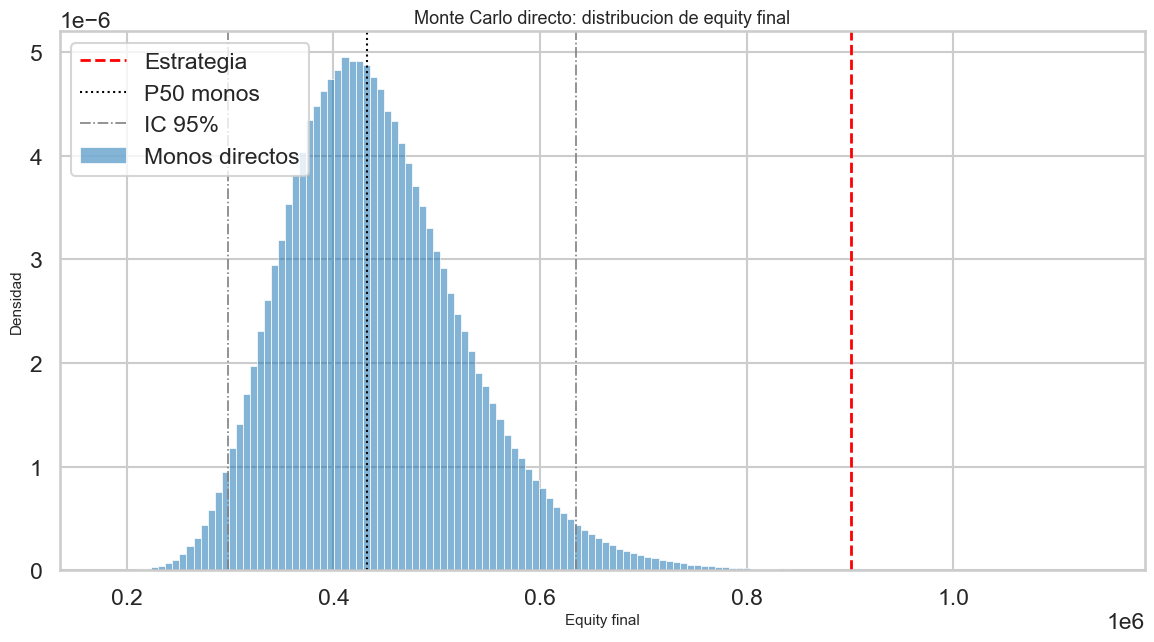

CSV directo guardados:
  data/processed/n5_mc_direct_summary.csv
  data/processed/n5_mc_direct_quantiles.csv
  data/processed/n5_mc_direct_sample.csv
Requisito <24h: PASS


In [13]:
# ================================================================
# 11C. Resultados del Monte Carlo directo (bloque principal)
# ================================================================
p_strat = float((monkey_wealth <= strategy_final_equity).mean() * 100)
p_monkey_beats = float((monkey_wealth > strategy_final_equity).mean())

p05, p50, p95 = np.percentile(monkey_wealth, [5, 50, 95])
ci_low, ci_high = np.percentile(monkey_wealth, [2.5, 97.5])

direct_summary_df = pd.DataFrame([{
    "n_monkeys": int(N_MONKEYS),
    "seed": int(MONKEY_SEED),
    "monkey_k": int(MONKEY_K),
    "monkey_cost": float(MONKEY_COST),
    "initial_capital": float(initial_capital),
    "mc_n_months": int(mc_n_months),
    "mc_month_start": str(mc_month_start),
    "mc_month_end": str(mc_month_end),
    "sampling": "without_replacement",
    "model": "direct_non_parametric",
    "runtime_sec": float(direct_elapsed) if np.isfinite(direct_elapsed) else np.nan,
    "runtime_min": float(direct_elapsed / 60) if np.isfinite(direct_elapsed) else np.nan,
    "runtime_lt_24h": bool(np.isfinite(direct_elapsed) and direct_elapsed < 24 * 3600),
    "mc_start_utc": str(mc_start) if pd.notna(mc_start) else "",
    "mc_end_utc": str(mc_end) if pd.notna(mc_end) else "",
    "strategy_final_equity": float(strategy_final_equity),
    "strategy_return_vs_initial_capital": float(strategy_return_vs_initial_capital),
    "strategy_return_from_first_valuation": float(strategy_return_from_first_valuation),
    "strategy_percentile": float(p_strat),
    "p_monkey_beats_strategy": float(p_monkey_beats),
    "p05": float(p05),
    "p50": float(p50),
    "p95": float(p95),
    "ci95_low": float(ci_low),
    "ci95_high": float(ci_high),
}])

direct_quant_df = pd.DataFrame([{
    "q01": float(np.percentile(monkey_wealth, 1)),
    "q05": float(p05),
    "q10": float(np.percentile(monkey_wealth, 10)),
    "q25": float(np.percentile(monkey_wealth, 25)),
    "q50": float(p50),
    "q75": float(np.percentile(monkey_wealth, 75)),
    "q90": float(np.percentile(monkey_wealth, 90)),
    "q95": float(p95),
    "q99": float(np.percentile(monkey_wealth, 99)),
}])

plot_n = min(MONKEY_PLOT_N, len(monkey_wealth))
plot_sample = monkey_wealth[rng.integers(0, len(monkey_wealth), size=plot_n)]
direct_sample_df = pd.DataFrame({"equity_final": plot_sample})

# Export CSV (directo)
direct_summary_df.to_csv(MC_DIRECT_SUMMARY_CSV, index=False)
direct_quant_df.to_csv(MC_DIRECT_QUANT_CSV, index=False)
direct_sample_df.to_csv(MC_DIRECT_SAMPLE_CSV, index=False)

display(direct_summary_df)
display(direct_quant_df)

plt.figure(figsize=(14, 7))
sns.histplot(plot_sample, bins=140, stat="density", color="tab:blue", alpha=0.55, label="Monos directos")
plt.axvline(strategy_final_equity, color="red", linestyle="--", linewidth=2, label="Estrategia")
plt.axvline(p50, color="black", linestyle=":", linewidth=1.5, label="P50 monos")
plt.axvline(ci_low, color="gray", linestyle="-.", linewidth=1.2, label="IC 95%")
plt.axvline(ci_high, color="gray", linestyle="-.", linewidth=1.2)
plt.title("Monte Carlo directo: distribucion de equity final")
plt.xlabel("Equity final")
plt.ylabel("Densidad")
plt.legend(loc="upper left")
plt.show()

print("CSV directo guardados:")
print(f"  {MC_DIRECT_SUMMARY_CSV}")
print(f"  {MC_DIRECT_QUANT_CSV}")
print(f"  {MC_DIRECT_SAMPLE_CSV}")
print(f"Requisito <24h: {'PASS' if np.isfinite(direct_elapsed) and direct_elapsed < 24*3600 else 'FAIL'}")



---

## 13. Respuestas obligatorias del enunciado (auditadas)

### 13.1 Sesgo de supervivencia

El pipeline no utiliza un universo est&aacute;tico de componentes actuales del &iacute;ndice. La selecci&oacute;n se construye con composici&oacute;n point-in-time (`in_sp500`) y ventana de elegibilidad de 13 meses, por lo que cada rebalanceo usa &uacute;nicamente informaci&oacute;n disponible en su fecha.

En ejecuci&oacute;n (N4), cuando un activo deja de ser invertible, se aplica salida forzosa y se conserva trazabilidad en el log de &oacute;rdenes.

Evidencia operativa:
- Universo PIT y elegibilidad mensual en N1-N3.
- Reglas de salida forzosa y control de precios proxy en N4.
- Checks: `forced_proxy_al_last_seen`, `forzadas_al_close`, `resumen_completo`.

Limitaci&oacute;n residual:
- Si no hay cotizaci&oacute;n de salida, se usa &uacute;ltimo precio observado como proxy.

### 13.2 Control de look-ahead

La se&ntilde;al de momentum se calcula con lags expl&iacute;citos (t-13 a t-1 y t-7 a t-1), excluyendo el mes de rebalanceo. En ejecuci&oacute;n (N4) se respeta la secuencia temporal ventas `OPEN` y compras `CLOSE`, sin redimensionar con precios de cierre del mismo d&iacute;a.

Evidencia operativa:
- Checks de ejecuci&oacute;n temporal: `salidas_al_open`, `entradas_al_close`, `strict_open_sin_proxy_rebalance`.
- Trazabilidad completa en `n4_orders_log.csv`.

### 13.3 Overfitting

La estrategia implementa reglas fijas del enunciado y no se basa en optimizaci&oacute;n masiva de hiperpar&aacute;metros sobre la muestra principal.

La robustez se eval&uacute;a con Monte Carlo **directo no param&eacute;trico** de gran escala (&gt;=25M), usando retornos forward observados y muestreo sin reemplazo.

Evidencia operativa:
- Percentil de la estrategia y `P(monkey > strategy)`.
- Tiempo de c&oacute;mputo reportado y validaci&oacute;n `<24h`.

### 13.4 Realismo del rebalanceo

El motor de N4 modela fricciones relevantes: secuencia OPEN/CLOSE, acciones enteras, comisi&oacute;n proporcional con m&iacute;nimo por orden y registro expl&iacute;cito de incidencias (`no_fill_cash`, `no_fill_at_close`, salidas forzosas con proxy).

Evidencia operativa:
- Logs de &oacute;rdenes y resumen por rebalanceo.
- Checks: `cash_no_negativo`, `identidad_contable`, `regla_comisiones`.

### 13.5 Impacto de comisiones

El an&aacute;lisis cuantifica comisiones en t&eacute;rminos absolutos y relativos (capital inicial y equity final), incluyendo el sobrecoste por comisi&oacute;n m&iacute;nima por orden. Esto separa retorno bruto y neto bajo condiciones operativas realistas.

## 14. Lectura ejecutiva de resultados

La estrategia se eval&uacute;a frente a SPY en ventana com&uacute;n diaria (**2015-01-30 -> 2026-01-30**) con las m&eacute;tricas exigidas del enunciado. En la tabla de m&eacute;tricas, la estrategia obtiene **CAGR 12.41%** frente a **13.78%** del benchmark; el ajuste por riesgo tambi&eacute;n queda por debajo de SPY (**Sharpe 0.611 vs 0.816**, **Sortino 0.786 vs 0.990**), con mayor riesgo realizado (**volatilidad 23.82% vs 17.75%** y **max drawdown -40.26% vs -33.72%**).

En t&eacute;rminos de exposici&oacute;n de mercado, la estrategia presenta **beta 1.045** y **alpha Jensen -0.59% anualizado**, por lo que el exceso de riesgo asumido no se traduce en una mejora de eficiencia frente al benchmark en esta muestra.

Desde la &oacute;ptica operativa, el coste es material: comisi&oacute;n total **$134,828.27**, equivalente a **53.93%** del capital inicial y **14.96%** de la equity final. El m&iacute;nimo por orden afecta a **1,632** &oacute;rdenes, con sobrecoste estimado de **$32,586.39**.

La prueba de robustez Monte Carlo directo no param&eacute;trico (muestreo sin reemplazo, costes incluidos) ubica la estrategia en el **percentil 99.99** de **25,000,000** carteras aleatorias. La probabilidad de que un mono supere a la estrategia es **0.0138%**, con mediana de monos en **$432,373** frente a equity final de estrategia **$901,326**. El tiempo de ejecuci&oacute;n registrado es **71.1 min**, cumpliendo el requisito `<24h`.

Nota de per&iacute;odo: el backtest operativo termina en **2026-01-30** por l&iacute;mite PIT del dataset operativo; SPY dispone de datos hasta **2026-02-27**, pero no se extiende la comparaci&oacute;n fuera de la ventana invertible del sistema.

## 15. Checklist de cumplimiento del enunciado

| Requisito del enunciado | Estado | C&oacute;mo se cumple en N5 |
|---|---|---|
| Tabla comparativa de m&eacute;tricas (CAGR, volatilidad, Sharpe, Sortino, max drawdown, beta, alpha) vs SPY | Cumplido | Se construye y muestra en la secci&oacute;n 3 (`metrics_show`). |
| Evoluci&oacute;n de rentabilidad acumulada estrategia vs SPY | Cumplido | Se visualiza en la secci&oacute;n 4 con serie base 100 y zonas de out/underperformance. |
| Histograma de retornos mensuales estrategia vs benchmark | Cumplido | Se presenta en la secci&oacute;n 5 (`histplot` mensual comparado). |
| An&aacute;lisis de recurrencia de retornos | Cumplido | Se cubre en la secci&oacute;n 7 (matriz de transici&oacute;n y rachas). |
| Scatter anual y trimestral estrategia vs SPY | Cumplido | Se incluye en la secci&oacute;n 6 con regresi&oacute;n y referencia diagonal. |
| Monte Carlo directo con al menos 25.000.000 de monos y coste 0,23% x2 | Cumplido | Se ejecuta en secciones 10-11 con `N_MONKEYS = 25_000_000` y `MONKEY_COST = 2*fee_rate`. |
| Evidencia de tiempo de ejecuci&oacute;n < 24h | Cumplido | Se imprime `runtime_sec/runtime_min` y flag `runtime_lt_24h` en el resumen del Monte Carlo. |
| Resumen cr&iacute;tico final (supervivencia, look-ahead, overfitting, realismo de rebalanceo, comisiones) | Cumplido | Se documenta en secci&oacute;n 13 y se refuerza con diagn&oacute;stico operativo en secci&oacute;n 9. |
| Impacto de comisi&oacute;n m&iacute;nima y costes operativos | Cumplido | Se cuantifica en secci&oacute;n 9 con tabla de m&eacute;tricas operativas y an&aacute;lisis por tipo de orden. |

In [14]:
# Verificacion de completitud
cagr_s = float(metrics.loc[metrics["metric"] == "CAGR", "strategy"].iloc[0])
cagr_b = float(metrics.loc[metrics["metric"] == "CAGR", "spy"].iloc[0])
sharpe_s = float(metrics.loc[metrics["metric"] == "Sharpe", "strategy"].iloc[0])
maxdd_s = float(metrics.loc[metrics["metric"] == "Max Drawdown", "strategy"].iloc[0])

ret_vs_initial_n4 = float(cost_summary["return_vs_initial_capital"].iloc[0])
ret_from_first_n4 = float(cost_summary["return_from_first_valuation"].iloc[0])

required = {
    "CAGR",
    "Volatility (annualized)",
    "Sharpe",
    "Sortino",
    "Max Drawdown",
    "Beta (vs SPY)",
    "Alpha Jensen (annualized)",
}
present = set(metrics["metric"].tolist())
metrics_ok = required.issubset(present)
mc_ok = bool(np.isfinite(direct_elapsed) and direct_elapsed < 24 * 3600 and N_MONKEYS >= 25_000_000)
n4_checks_ok = len(n4_critical_failed) == 0

print("=" * 60)
print("  NOTEBOOK 5 - RESUMEN FINAL")
print("=" * 60)
print(f"  Ventana:              {returns_daily.index.min().date()} -> {returns_daily.index.max().date()}")
print(f"  CAGR estrategia:      {cagr_s:.4f} ({cagr_s:.2%})")
print(f"  CAGR SPY:             {cagr_b:.4f} ({cagr_b:.2%})")
print(f"  Sharpe estrategia:    {sharpe_s:.4f}")
print(f"  Max Drawdown:         {maxdd_s:.4f} ({maxdd_s:.2%})")
print(f"  Return vs capital:    {ret_vs_initial_n4:.2%}")
print(f"  Return desde val. 1:  {ret_from_first_n4:.2%}")
print(f"  Fee total:            ${total_fee:,.2f} ({100 * total_fee / final_eq:.1f}% equity final)")
print(f"  no_fill_cash:         {len(no_fill_cash_df)} ordenes")
print(f"  forced proxy exits:   {len(forced_proxy_df)} ordenes")
print("  ---")
print(f"  MC monos:             {N_MONKEYS:,}")
print(f"  MC tiempo:            {direct_elapsed/60:.1f} min (<24h: {'PASS' if mc_ok else 'FAIL'})")
print(f"  MC percentil:         {p_strat:.2f}%")
print(f"  MC P(monkey>strat):   {p_monkey_beats:.6f}")
print("  ---")
print(f"  Metricas completas:   {'PASS' if metrics_ok else 'FAIL'}")
print(f"  Monte Carlo valido:   {'PASS' if mc_ok else 'FAIL'}")
print(f"  Checks criticos N4:   {'PASS' if n4_checks_ok else 'FAIL'}")
print("=" * 60)
if metrics_ok and mc_ok and n4_checks_ok:
    print("  STATUS: PASS - Analisis completo. Pipeline defendible.")
else:
    print("  STATUS: FAIL - Revisar items marcados.")
print("=" * 60)



  NOTEBOOK 5 - RESUMEN FINAL
  Ventana:              2015-01-30 -> 2026-01-30
  CAGR estrategia:      0.1241 (12.41%)
  CAGR SPY:             0.1378 (13.78%)
  Sharpe estrategia:    0.6109
  Max Drawdown:         -0.4026 (-40.26%)
  Return vs capital:    260.53%
  Return desde val. 1:  261.35%
  Fee total:            $134,828.27 (15.0% equity final)
  no_fill_cash:         174 ordenes
  forced proxy exits:   16 ordenes
  ---
  MC monos:             25,000,000
  MC tiempo:            63.6 min (<24h: PASS)
  MC percentil:         99.99%
  MC P(monkey>strat):   0.000138
  ---
  Metricas completas:   PASS
  Monte Carlo valido:   PASS
  Checks criticos N4:   PASS
  STATUS: PASS - Analisis completo. Pipeline defendible.
